In [18]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
from scipy import stats
import numpy as np

In [3]:
# Set the path to the file you'd like to load
file_path = "wildfire_events.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "meruvakodandasuraj/global-wildfire-intelligence-20012026",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

<Axes: xlabel='air_temp_celsius', ylabel='country'>

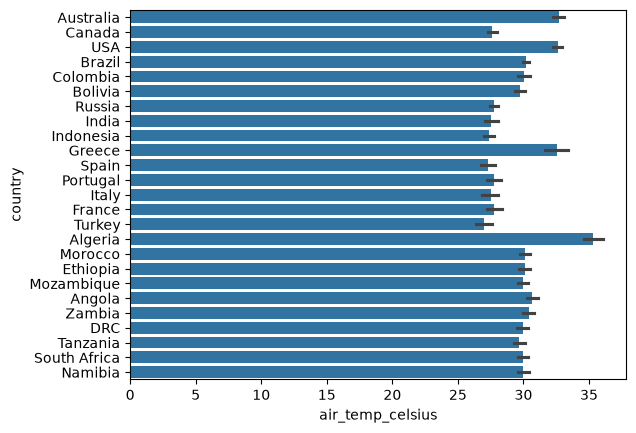

In [4]:
sns.barplot(x=df["air_temp_celsius"], y=df['country'])

<Axes: >

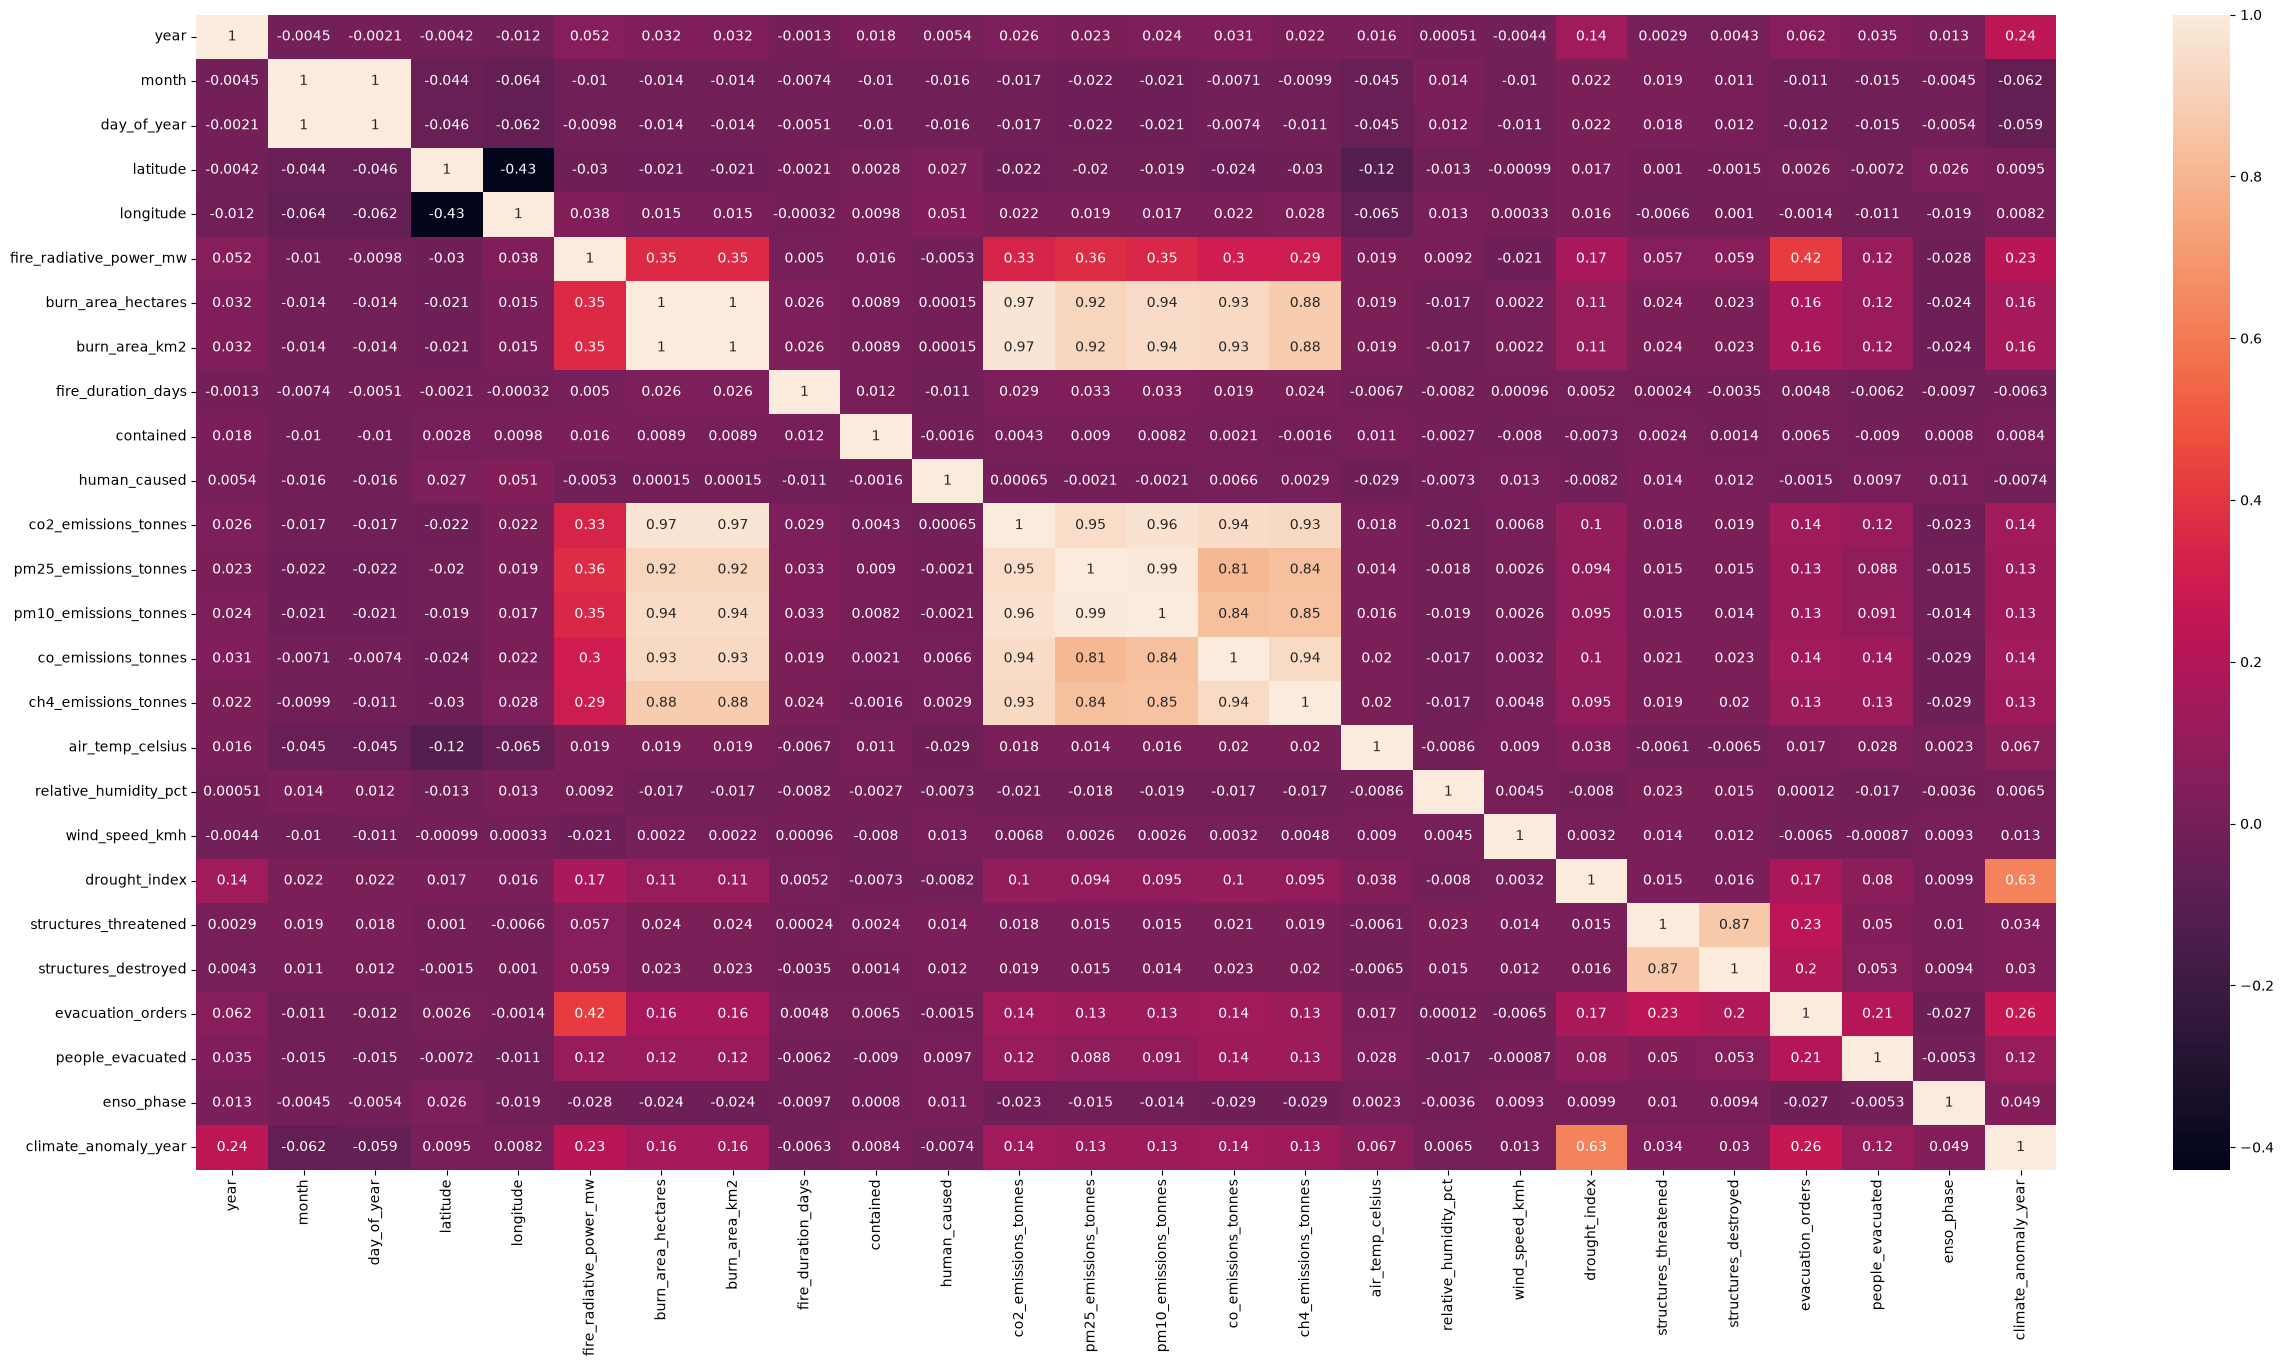

In [5]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(30,15))
sns.heatmap(numeric_df.corr(), annot=True)

Magnitudes > 0.5:

Burn area & Emission tonnes
Emissions & Emissions

<Axes: xlabel='burn_area_km2'>

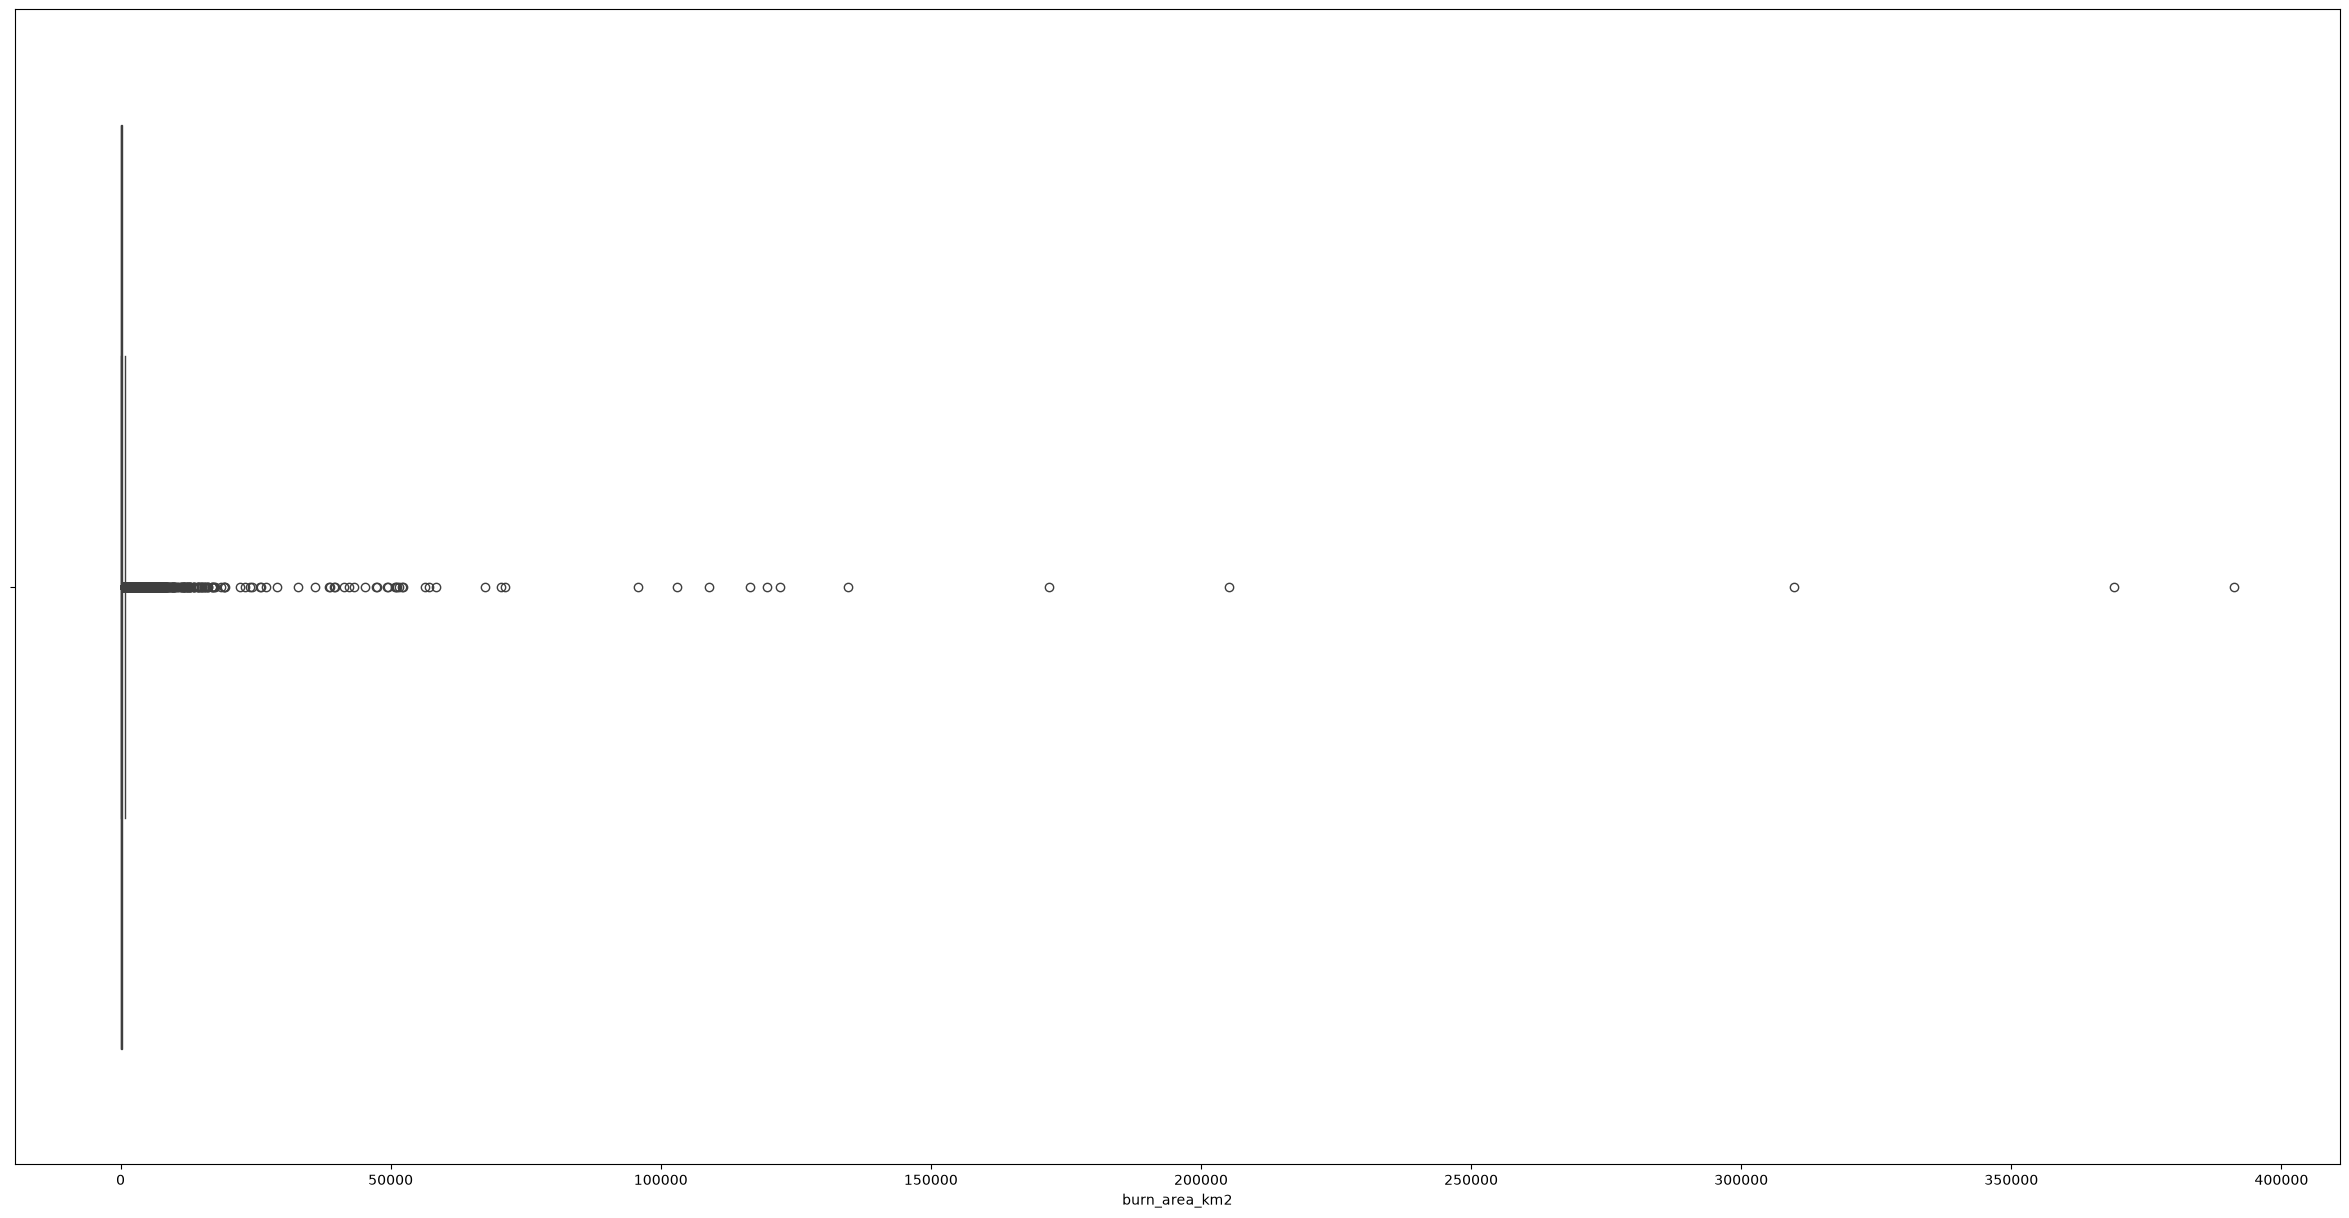

In [6]:
plt.figure(figsize=(30,15))
sns.boxplot(x=df["burn_area_km2"])

<Axes: >

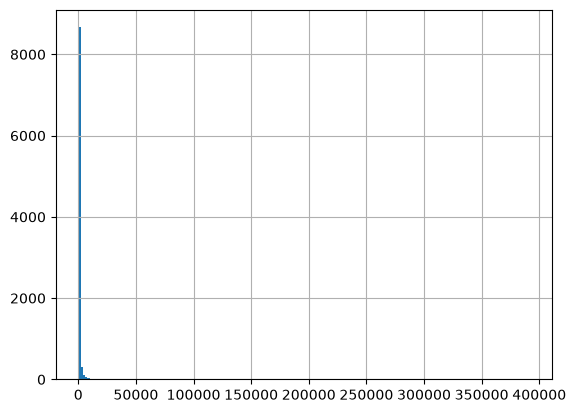

In [7]:
df["burn_area_km2"].hist(bins=200)

In [8]:
burn_area = df["burn_area_km2"]

mean_burn_area = burn_area.mean()
std_burn_area = burn_area.std()

df["z_score_burn_area"] = (df["burn_area_km2"] - mean_burn_area) / std_burn_area
print(df["z_score_burn_area"])

0      -0.097649
1      -0.105577
2       0.031654
3      -0.055060
4      -0.060253
          ...   
9272   -0.103859
9273   -0.109237
9274   -0.109015
9275   -0.088617
9276   -0.109435
Name: z_score_burn_area, Length: 9277, dtype: float64


In [ ]:
Q1 = df["burn_area_km2"].quantile(0.25)
Q3 = df["burn_area_km2"].quantile(0.75)

iqr = Q3 - Q1

lower_bound = Q1 - 1.5*iqr
upper_bound = Q3 + 1.5*iqr 

# clean_df = df[df["burn_area_km2"] <= upper_bound]
# clean_df

,event_id,date,year,month,day_of_year,season,region_id,region_name,country,continent,...,wind_speed_kmh,wind_direction,drought_index,structures_threatened,structures_destroyed,evacuation_orders,people_evacuated,enso_phase,climate_anomaly_year,z_score_burn_area
0,WF0000001,2001-02-01,2001,2,32,Summer,aus_nsw,New South Wales,Australia,Oceania,...,18.0,NW,0.816,12,3,1,13,0.000,0,-0.097649
1,WF0000002,2001-02-13,2001,2,44,Summer,aus_nsw,New South Wales,Australia,Oceania,...,5.1,SE,0.522,1,0,0,0,0.000,0,-0.105577
3,WF0000004,2001-11-22,2001,11,326,Autumn,aus_nsw,New South Wales,Australia,Oceania,...,26.3,SW,0.461,0,0,0,0,0.000,0,-0.055060
4,WF0000005,2001-12-01,2001,12,335,Summer,aus_nsw,New South Wales,Australia,Oceania,...,37.0,SW,0.609,1,0,1,157,0.000,0,-0.060253
5,WF0000006,2001-12-18,2001,12,352,Summer,aus_nsw,New South Wales,Australia,Oceania,...,11.8,S,0.789,0,0,0,0,0.000,0,-0.100783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9272,WF0009273,2026-12-02,2026,12,336,Summer,nam_osh,Oshikoto,Namibia,Africa,...,27.9,NW,0.338,0,0,0,0,-0.476,0,-0.103859
9273,WF0009274,2026-12-02,2026,12,336,Summer,nam_osh,Oshikoto,Namibia,Africa,...,26.1,N,0.565,0,0,0,0,-0.476,0,-0.109237
9274,WF0009275,2026-12-24,2026,12,358,Summer,nam_osh,Oshikoto,Namibia,Africa,...,22.0,N,0.222,7,0,0,0,-0.476,0,-0.109015
9275,WF0009276,2026-12-27,2026,12,361,Summer,nam_osh,Oshikoto,Namibia,Africa,...,17.8,SE,0.517,0,0,0,0,-0.476,0,-0.088617


In [22]:
df["log_burn_area"] = np.log(df["burn_area_km2"])

df["log_co2_emmissions"] = np.log(df["co2_emissions_tonnes"])

<Axes: >

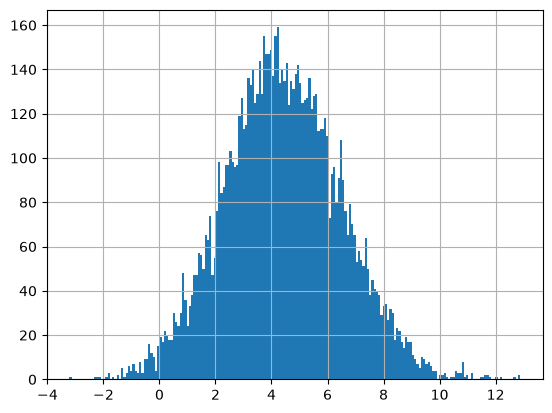

In [20]:
df["log_burn_area"].hist(bins=200)

<Axes: xlabel='burn_area_km2', ylabel='vegetation_type'>

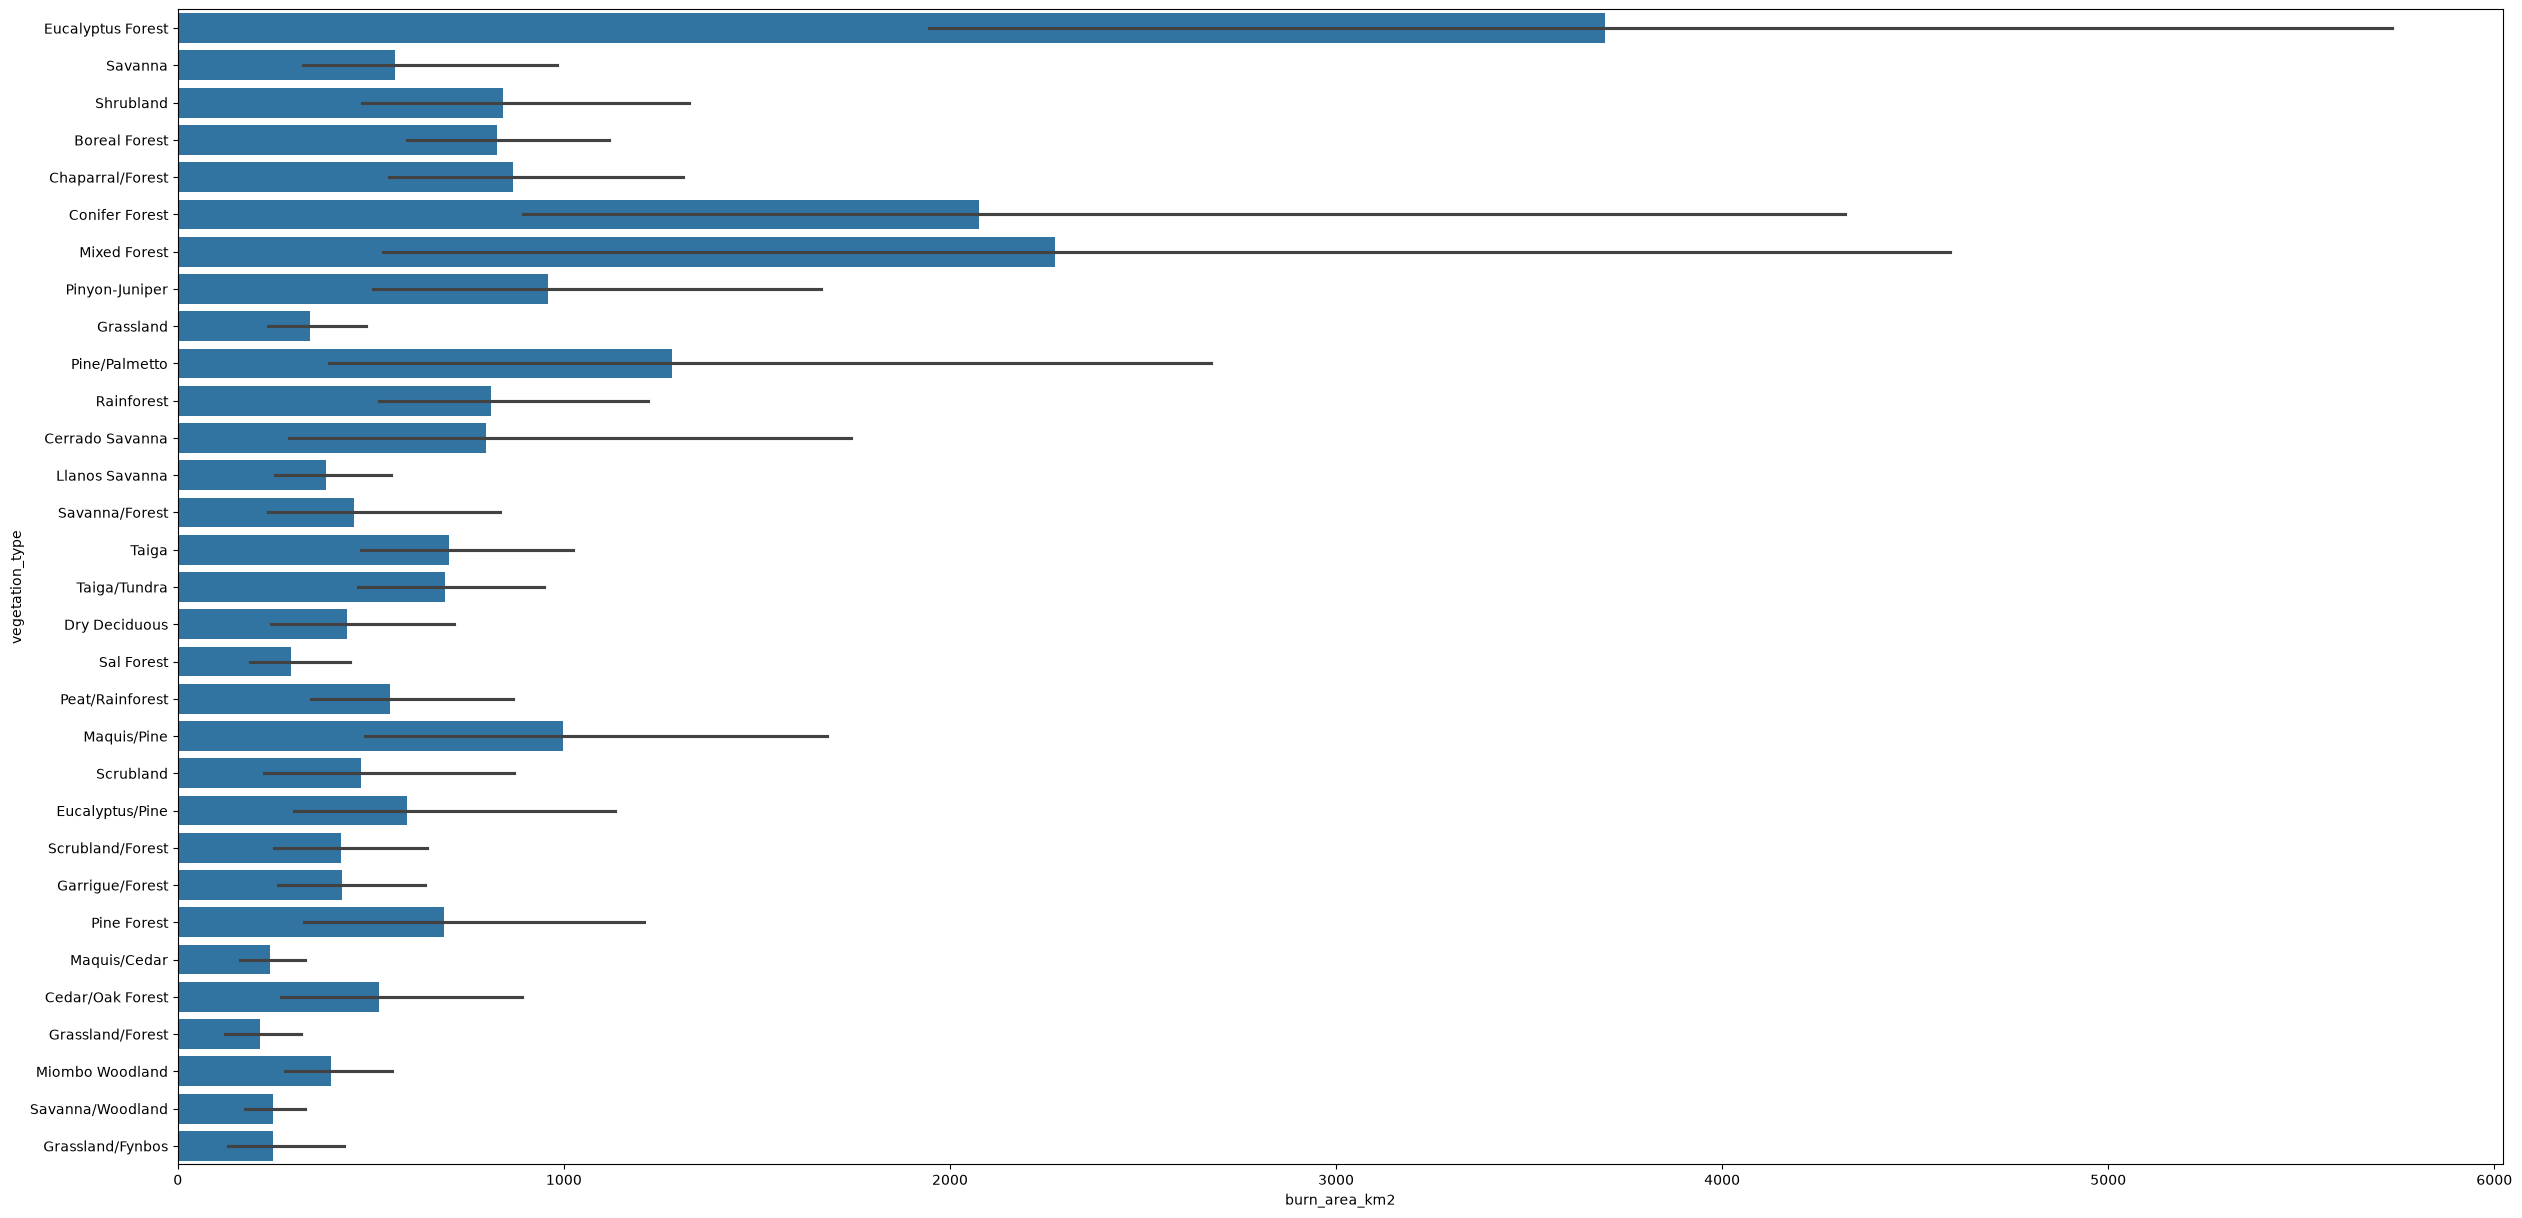

In [11]:
plt.figure(figsize=(30,15))
sns.barplot(x=df["burn_area_km2"], y=df["vegetation_type"])

<Axes: xlabel='log_burn_area', ylabel='log_co2_emmissions'>

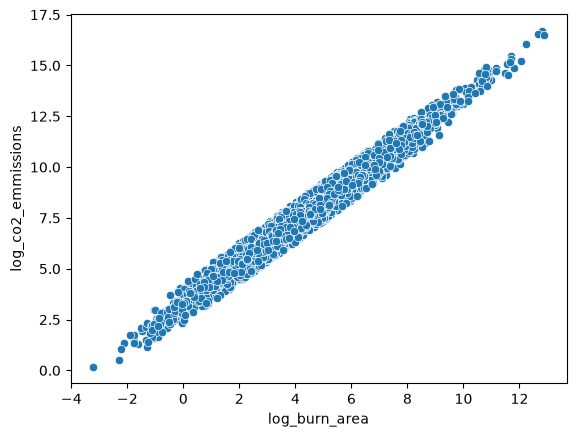

In [23]:
sns.scatterplot(x=df["log_burn_area"], y=df["log_co2_emmissions"])

<bound method IndexOpsMixin.value_counts of 0       Eucalyptus Forest
1       Eucalyptus Forest
2       Eucalyptus Forest
3       Eucalyptus Forest
4       Eucalyptus Forest
              ...        
9272              Savanna
9273              Savanna
9274              Savanna
9275              Savanna
9276              Savanna
Name: vegetation_type, Length: 9277, dtype: str>


<Axes: xlabel='log_burn_area', ylabel='log_co2_emmissions'>

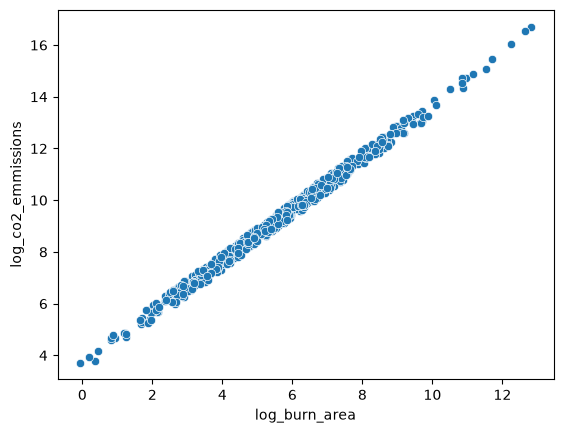

In [34]:
eucalyptus_forest_df = df[df["vegetation_type"] == "Eucalyptus Forest"]

print(df["vegetation_type"].value_counts)

sns.scatterplot(x=eucalyptus_forest_df["log_burn_area"], y=eucalyptus_forest_df["log_co2_emmissions"])

In [ ]:
for vegetation_type in df["vegetation_type"].unique():
    veg_type_df = df[df["vegetation_type"] == vegetation_type]

    slope, intercept, r, p, std_err = stats.linregress(veg_type_df["log_burn_area"], veg_type_df["log_co2_emmissions"])
    print(f"{vegetation_type}: {r}")

0.9855257697405967
0.9965077998738997
Eucalyptus Forest: 0.9965077998738997
Savanna: 0.9963686474274013
Shrubland: 0.996608738632989
Boreal Forest: 0.9959614241012537
Chaparral/Forest: 0.9962813579939935
Conifer Forest: 0.9963082623099968
Mixed Forest: 0.9966402036193076
Pinyon-Juniper: 0.9966397145658932
Grassland: 0.99583968149144
Pine/Palmetto: 0.9962313690666856
Rainforest: 0.9958164247177748
Cerrado Savanna: 0.9959974254565646
Llanos Savanna: 0.9964820704538757
Savanna/Forest: 0.9956818107174742
Taiga: 0.9961298600614842
Taiga/Tundra: 0.995824777112451
Dry Deciduous: 0.9964554803586471
Sal Forest: 0.9957197840272369
Peat/Rainforest: 0.9962092351493588
Maquis/Pine: 0.9969246778248378
Scrubland: 0.9958275215133104
Eucalyptus/Pine: 0.9965166133214606
Scrubland/Forest: 0.995741198822826
Garrigue/Forest: 0.9967384390090892
Pine Forest: 0.9961776180554204
Maquis/Cedar: 0.9960336630268866
Cedar/Oak Forest: 0.9959224131796283
Grassland/Forest: 0.9952406689182368
Miombo Woodland: 0.9958794

In [60]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()

# vegetation_encoded = encoder.fit(df, df["vegetation_type"])


# encoded_df = pd.DataFrame(vegetation_encoded)

encoded_df = pd.get_dummies(df["vegetation_type"], dtype=int)